In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator, RBFInterpolator

sys.path.append('C:\\Users\\Mark\\PycharmProjects\\approximationMap')
from control.experiment_data import ExperimentData
from control.database import DatabaseHandler

# Исходные данные

In [2]:
db = DatabaseHandler()
df = db.get_all_experiment_data()

diesel_air = df.loc[(df['fuel_id'] == 1) & (df['F_air'].notna())]
diesel_steam = df.loc[(df['fuel_id'] == 1) & (df['F_steam'].notna())]

crude_oil_steam = df.loc[(df['fuel_id'] == 2) & (df['F_steam'].notna())]

heavy_oil_air = df.loc[(df['fuel_id'] == 3) & (df['F_air'].notna())]
heavy_oil_steam = df.loc[(df['fuel_id'] == 3) & (df['F_steam'].notna())]

kerosene_air = df.loc[(df['fuel_id'] == 4) & (df['F_air'].notna())]
kerosene_steam = df.loc[(df['fuel_id'] == 4) & (df['F_steam'].notna())]

waste_oil_steam = df.loc[(df['fuel_id'] == 5) & (df['F_steam'].notna())]

dfs = {
    'diesel_air': diesel_air, 
    'diesel_steam': diesel_steam, 
    'crude_oil_steam': crude_oil_steam, 
    'heavy_oil_air': heavy_oil_air, 
    'heavy_oil_steam': heavy_oil_steam, 
    'kerosene_air': kerosene_air, 
    'kerosene_steam': kerosene_steam, 
    'waste_oil_steam': waste_oil_steam
}

# Суммарное значение воздуха

In [4]:
sum_air_coef = {
    'diesel': 14.431,
    'crude_oil': 13.775,
    'heavy_oil': 13.660,
    'kerosene': 14.523,
    'waste_oil': 14.408
}

for key in dfs:
    if key.count('_') == 1:
        fuel_type = key.split('_')[0]
        dfs[key] = dfs[key].copy()
        dfs[key].loc[:, 'sum_air'] = dfs[key]['F_fuel'] * sum_air_coef[fuel_type] * 21 / (21 - dfs[key]['O2'])
    else:
        fuel_type = key.split('_')[0] + '_' + key.split('_')[1]
        dfs[key] = dfs[key].copy()
        dfs[key].loc[:, 'sum_air'] = dfs[key]['F_fuel'] * sum_air_coef[fuel_type] * 21 / (21 - dfs[key]['O2'])


# Импульс струи

## Расчет струи

In [5]:
steam_params = pd.DataFrame({
    "Cp": [2.139108184, 2.079572787],  # теплоемкость (Дж/(кг*К)) Cp
    "adiabat": [1.302022264, None],  # показатель адиабаты kg
    "mol_mass": [0.018, None],  # молярная масса (кг/моль)
    "G": [0.000222222, None],  # mass flowrate (kg/s) G
    "G_hr": [0.8, None],  # mass flowrate (кг/ч) G_hr
    "D_tube": [0.003, None],  # диаметр отверстия трубки
    "D_jet": [0.0006, None],  # диаметр отверстия форсунки
    "P": [7.4, 1.01],  # P (bar)
    "T": [523.15, 329.6083348],  # T (K)
    "t": [250, 56.60833484],  # t_C (C)
    "rho": [3.063916824, 0.663734924],  # rho (kg/m3)
    "U": [10.26072679, 931.3243951],  # U (m/s)
    "Q": [4.351728228, 20.08834076],  # Q (л/мин)
    "Y_jet": [0.002280162, 0.207]  # Yjet (N)
}, index=["input_tube", "jet"]
)

air_params = pd.DataFrame({
    "Cp": [1.006, 1.006],  # теплоемкость (Дж/(кг*К)) Cp
    "adiabat": [1.4, None],  # показатель адиабаты kg
    "mol_mass": [0.029, None],  # молярная масса (кг/моль)
    "G": [0.000287778, None],  # mass flowrate (kg/s) G
    "G_hr": [1.036, None],  # mass flowrate (кг/ч) G_hr
    "D_tube": [0.003, None],  # диаметр отверстия трубки
    "D_jet": [0.0006, None],  # диаметр отверстия форсунки
    "P": [7.8, 1.01],  # P (bar)
    "T": [523.15, 291.7270737],  # T (K)
    "t": [250, 18.72707372],  # t_C (C)
    "rho": [5.20313803, 1.208207736],  # rho (kg/m3)
    "U": [7.824552641, 682.4105445],  # U (m/s)
    "Q": [3.318510208, 14.29114063],  # Q (л/мин)
    "Y_jet": [0.002251732, 0.196]  # Yjet (N)
}, index=["input_tube", "jet"])


## Струя выбросы

In [6]:
for key in dfs:
    st_prm_tube = steam_params.loc['input_tube']
    st_prm_jet = steam_params.loc['jet']

    air_prm_tube = air_params.loc['input_tube']
    air_prm_jet = air_params.loc['jet']
    
    if 'steam' in key:
        dfs[key] = dfs[key].copy()
        
        P_abs = 7.8 * dfs[key]['F_steam']
        ro_tube = P_abs * 100_000 * st_prm_tube['mol_mass'] / st_prm_tube['T'] / 8.31
        ro_atm = ((st_prm_jet['P'] / P_abs) ** (1 / st_prm_tube['adiabat'])) * ro_tube
        T_atm = st_prm_jet['P'] * 100_000 / ro_atm / 8.31 * st_prm_tube['mol_mass']
        U_tube = dfs[key]['F_steam'] / 3_600 / np.pi / ro_tube / st_prm_tube['D_tube'] / st_prm_tube['D_tube'] * 4
        U_atm = np.sqrt(-2 * st_prm_jet['Cp'] * 1_000 * T_atm + U_tube * U_tube + 2 * st_prm_tube['Cp'] * 1_000 * st_prm_tube['T'])
        dfs[key].loc[:, 'J'] = U_atm * dfs[key]['F_steam'] / 3_600
        
    else:
        dfs[key] = dfs[key].copy()
        
        P_abs = 7.8 * dfs[key]['F_air']
        ro_tube = P_abs * 100_000 * air_prm_tube['mol_mass'] / air_prm_tube['T'] / 8.31
        ro_atm = ((air_prm_jet['P'] / P_abs) ** (1 / air_prm_tube['adiabat'])) * ro_tube
        T_atm = air_prm_jet['P'] * 100_000 / ro_atm / 8.31 * air_prm_tube['mol_mass']
        U_tube = dfs[key]['F_air'] / 3_600 / np.pi / ro_tube / air_prm_tube['D_tube'] / air_prm_tube['D_tube'] * 4
        U_atm = np.sqrt(-2 * air_prm_jet['Cp'] * 1_000 * T_atm + U_tube * U_tube + 2 * air_prm_tube['Cp'] * 1_000 * air_prm_tube['T'])
        dfs[key].loc[:, 'J'] = U_atm * dfs[key]['F_air'] / 3_600
        

# Построение графиков

In [7]:
dfs['diesel_steam'] = dfs['diesel_steam'].round(3)
pivoted = dfs['diesel_steam'].pivot_table(index='J', values='sum_air', columns='F_fuel')

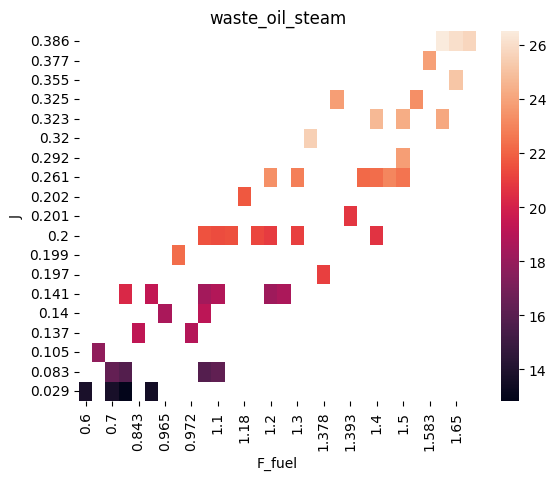

In [8]:
ax = sns.heatmap(data=pivoted)

ax.set_title('waste_oil_steam')

ax.invert_yaxis()

    F_fuel      J  sum_air
1      0.8  0.060   14.552
2      0.9  0.060   14.302
4      0.8  0.087   16.437
5      0.9  0.087   16.148
6      1.0  0.087   15.984
8      0.8  0.115   18.664
9      1.0  0.115   18.147
10     1.1  0.115   17.961
12     0.8  0.144   20.563
13     1.0  0.144   19.704
14     1.1  0.144   19.831
15     1.2  0.144   19.604
17     0.9  0.170   21.646
18     1.0  0.170   21.074
19     1.2  0.170   21.279
20     1.3  0.170   21.124
22     0.9  0.198   23.252
23     1.0  0.198   22.482
24     1.2  0.198   22.421
25     1.3  0.198   22.096
26     1.4  0.198   21.983
28     0.7  0.032   12.333
29     0.6  0.032   12.319
30     0.5  0.032   12.723
32     0.7  0.060   14.266
33     0.6  0.060   14.771
34     0.5  0.060   15.557
35     0.7  0.087   16.457
36     0.6  0.087   17.170
37     0.7  0.115   18.857
F_fuel     0.5     0.6     0.7     0.8     0.9     1.0     1.1     1.2  \
J                                                                        
0.032   12.723 

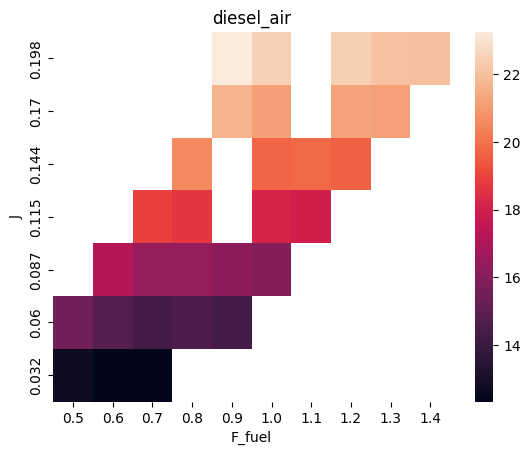

     F_fuel      J  sum_air
46    0.600  0.029   13.765
47    0.700  0.029   13.695
48    0.800  0.029   12.834
49    0.900  0.029   13.516
52    0.700  0.083   16.356
53    0.800  0.083   15.804
54    1.000  0.083   15.867
55    1.100  0.083   16.214
58    0.800  0.141   20.254
59    0.900  0.141   19.357
60    1.000  0.141   18.344
61    1.100  0.141   18.834
62    1.200  0.141   18.201
63    1.250  0.141   18.615
65    1.100  0.200   21.383
66    1.000  0.200   21.554
67    1.200  0.200   20.900
68    1.400  0.200   20.676
69    1.300  0.200   21.034
72    1.200  0.261   23.387
73    1.300  0.261   22.839
74    1.400  0.261   22.318
75    1.500  0.261   22.515
77    1.500  0.292   23.775
79    1.400  0.323   24.710
80    1.500  0.323   24.257
81    1.600  0.323   24.123
85    1.650  0.355   25.115
87    1.600  0.386   26.496
88    1.650  0.386   26.043
89    1.700  0.386   25.721
92    0.965  0.140   18.559
93    1.180  0.202   21.699
94    1.377  0.320   25.524
95    1.378  0.197  

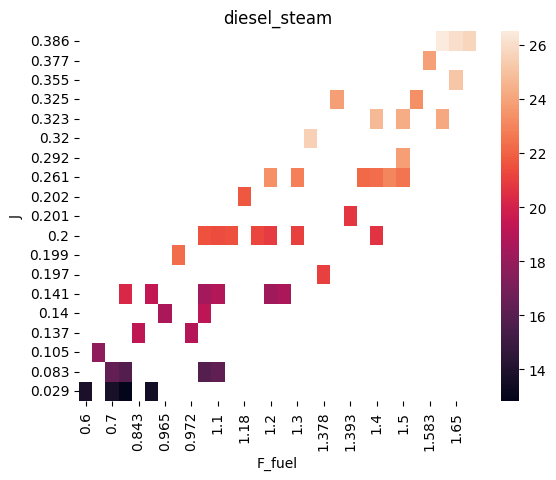

     F_fuel      J  sum_air
111     1.0  0.141   14.804
112     0.8  0.141   15.679
113     0.7  0.141   16.109
116     0.9  0.083   13.057
117     0.8  0.083   13.416
118     0.7  0.083   14.082
123     0.8  0.029   11.954
124     1.0  0.200   17.542
125     0.9  0.200   18.373
126     0.8  0.200   18.891
127     1.1  0.200   17.350
128     1.2  0.200   17.227
131     1.0  0.261   19.414
132     0.9  0.261   20.182
133     1.1  0.261   19.426
134     1.2  0.261   19.221
135     1.3  0.261   19.455
138     1.3  0.323   22.424
139     1.4  0.323   20.940
140     1.2  0.323   23.219
141     1.1  0.323   22.616
142     1.0  0.323   22.635
145     1.5  0.386   22.161
146     1.4  0.386   22.424
147     1.3  0.386   23.358
148     1.2  0.386   23.204
149     1.1  0.386   23.961
F_fuel     0.7     0.8     0.9     1.0     1.1     1.2     1.3     1.4     1.5
J                                                                             
0.029      NaN  11.954     NaN     NaN     NaN     NaN    

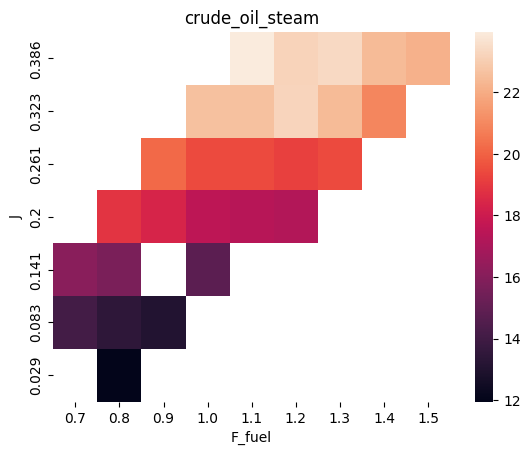

     F_fuel      J  sum_air
199    0.83  0.144   16.767
200    0.70  0.144   17.163
201    0.60  0.144   16.941
203    0.93  0.144   15.359
205    1.00  0.198   17.375
206    0.93  0.198   18.787
207    0.80  0.198   19.648
208    0.90  0.198   18.763
209    0.70  0.198   19.015
212    0.55  0.072   11.449
213    0.60  0.072   11.104
214    0.65  0.072   10.981
215    0.68  0.072   10.867
217    0.50  0.072   11.972
F_fuel    0.50    0.55    0.60    0.65    0.68    0.70    0.80    0.83  \
J                                                                        
0.072   11.972  11.449  11.104  10.981  10.867     NaN     NaN     NaN   
0.144      NaN     NaN  16.941     NaN     NaN  17.163     NaN  16.767   
0.198      NaN     NaN     NaN     NaN     NaN  19.015  19.648     NaN   

F_fuel    0.90    0.93    1.00  
J                               
0.072      NaN     NaN     NaN  
0.144      NaN  15.359     NaN  
0.198   18.763  18.787  17.375  


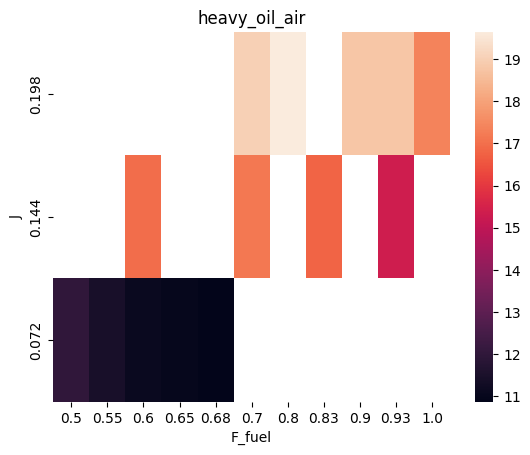

     F_fuel      J  sum_air
153    0.50  0.141   13.831
154    0.80  0.141   15.937
155    0.83  0.141   16.077
156    0.90  0.141   16.056
157    0.95  0.141   15.826
158    1.02  0.141   15.247
161    0.80  0.261   18.919
162    0.85  0.261   18.858
163    0.90  0.261   18.983
164    0.93  0.261   19.083
165    1.05  0.261   19.063
166    1.08  0.261   18.925
167    1.10  0.261   18.324
169    0.95  0.386   21.142
170    1.10  0.386   21.867
171    1.30  0.386   22.670
172    1.35  0.386   22.780
174    0.60  0.141   17.689
175    0.65  0.141   17.410
176    0.73  0.141   15.386
177    0.80  0.141   15.948
178    0.88  0.141   16.171
179    0.93  0.141   15.210
180    0.95  0.141   14.739
183    0.65  0.261   16.920
184    0.70  0.261   17.104
185    0.80  0.261   17.845
186    0.90  0.261   17.409
187    1.00  0.261   17.106
188    1.10  0.261   16.775
191    0.80  0.386   21.711
192    0.90  0.386   22.450
193    1.05  0.386   23.568
194    1.10  0.386   22.604
195    1.20  0.386  

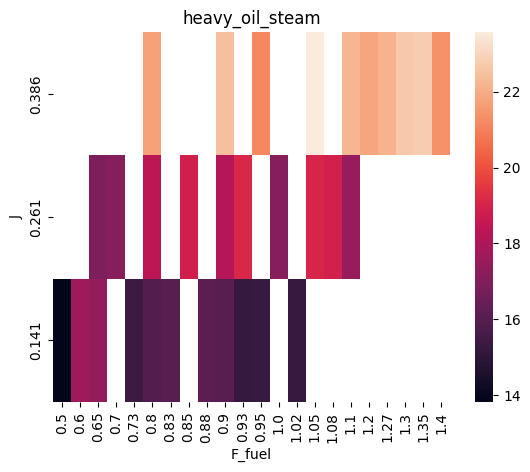

     F_fuel      J  sum_air
236    0.76  0.187   18.009
237    0.76  0.214   16.871
238    0.76  0.262   14.154
239    0.76  0.289   12.713
240    0.51  0.167   13.274
241    0.51  0.187   11.908
242    0.51  0.214   10.788
243    0.51  0.262    9.116
244    0.51  0.283    8.535
245    1.03  0.201   26.260
246    1.03  0.214   24.829
247    1.03  0.262   20.749
248    1.03  0.303   17.733
F_fuel    0.51    0.76    1.03
J                             
0.167   13.274     NaN     NaN
0.187   11.908  18.009     NaN
0.201      NaN     NaN  26.260
0.214   10.788  16.871  24.829
0.262    9.116  14.154  20.749
0.283    8.535     NaN     NaN
0.289      NaN  12.713     NaN
0.303      NaN     NaN  17.733


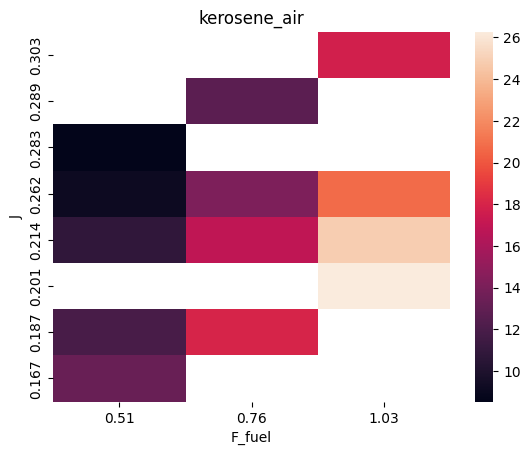

     F_fuel      J  sum_air
218     0.6  0.258   14.824
219     0.6  0.295   13.393
220     0.6  0.361   11.255
221     0.6  0.399   10.070
222     0.4  0.231   10.355
223     0.4  0.258    9.290
224     0.4  0.295    8.519
225     0.4  0.361    7.144
226     0.4  0.389    6.532
227     0.8  0.277   19.980
228     0.8  0.295   18.990
229     0.8  0.361   15.565
230     0.8  0.418   13.244
231     1.2  0.342   28.797
232     1.2  0.361   27.388
233     1.2  0.389   25.490
234     1.2  0.418   22.830
235     1.2  0.466   19.594
F_fuel     0.4     0.6     0.8     1.2
J                                     
0.231   10.355     NaN     NaN     NaN
0.258    9.290  14.824     NaN     NaN
0.277      NaN     NaN  19.980     NaN
0.295    8.519  13.393  18.990     NaN
0.342      NaN     NaN     NaN  28.797
0.361    7.144  11.255  15.565  27.388
0.389    6.532     NaN     NaN  25.490
0.399      NaN  10.070     NaN     NaN
0.418      NaN     NaN  13.244  22.830
0.466      NaN     NaN     NaN  19.594


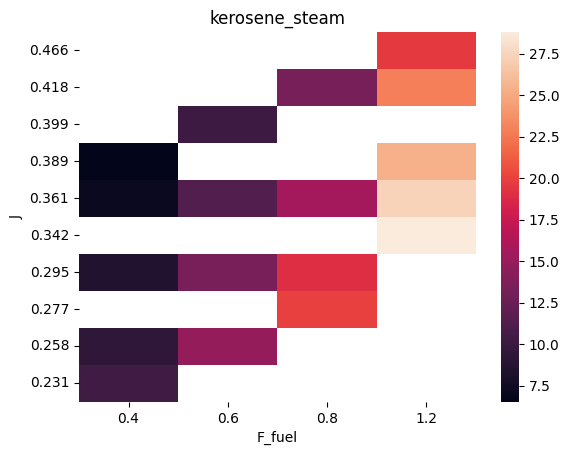

     F_fuel      J  sum_air
249   0.405  0.209    8.457
250   0.532  0.251    9.908
251   0.598  0.314    9.659
253   0.495  0.207   10.857
254   0.598  0.265   10.673
255   0.705  0.305   11.080
F_fuel  0.405   0.495  0.532   0.598  0.705
J                                          
0.207     NaN  10.857    NaN     NaN    NaN
0.209   8.457     NaN    NaN     NaN    NaN
0.251     NaN     NaN  9.908     NaN    NaN
0.265     NaN     NaN    NaN  10.673    NaN
0.305     NaN     NaN    NaN     NaN  11.08
0.314     NaN     NaN    NaN   9.659    NaN


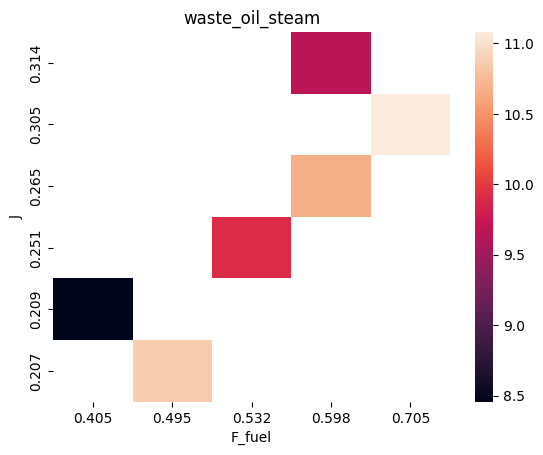

In [46]:
for key in dfs:
    #dfs[key] = dfs[key].round(3)
    dfs[key] = dfs[key].dropna(subset=['sum_air'])
    print(dfs[key][['F_fuel', 'J', 'sum_air']])
    pivoted = dfs[key].pivot_table(index='J', values='sum_air', columns='F_fuel')
    print(pivoted)
    
    ax = sns.heatmap(data=pivoted)
    ax.set_title(key)
    ax.invert_yaxis()
    
    plt.show()
    plt.close()
    

# Разбор ошибок

Почему нет значений расхода топлива > 0.7 у waste_oil?

Потому что отсутствуют значения кислорода по газовому анализу для данного расхода топлива

In [15]:
dfs['waste_oil_steam'][['F_fuel', 'O2']].loc[dfs['waste_oil_steam']['F_fuel'] > 0.71]

,F_fuel,O2
252,0.788772,NaN
256,0.802200,NaN
276,0.800000,NaN
277,0.800000,NaN
278,0.800000,NaN
279,0.800000,NaN
280,0.800000,NaN
281,1.000000,NaN
282,1.000000,NaN
283,1.000000,NaN


In [28]:
dfs['kerosene_steam'].loc[dfs['kerosene_steam']['sum_air'].notna()]

,experiment_id,fuel_id,F_fuel,F_air,F_steam,O2,CO,NO,NO2,NOx,CO2,SO2,P_air,P_steam,comments,t_wg,sum_air,J
218,2374,4,0.6,NaN,0.99,8.655667,56.470000,22.640000,3.580000,26.220000,9.630333,3.633333,NaN,4.5,None,24.993333,14.823790,0.258103
219,2375,4,0.6,NaN,1.11,7.336833,29.075000,27.613333,2.931667,30.545000,10.640000,3.766667,NaN,4.5,None,24.491667,13.392927,0.295170
220,2376,4,0.6,NaN,1.32,4.741833,16.386667,41.320000,2.060000,43.380000,12.571167,6.450000,NaN,4.5,None,25.101667,11.255254,0.360848
221,2377,4,0.6,NaN,1.44,2.828667,21.133333,46.868333,2.170000,49.038333,14.064000,8.650000,NaN,4.5,None,25.700000,10.070246,0.398775
222,2378,4,0.4,NaN,0.90,9.218387,64.396774,25.590323,4.977419,30.567742,9.226774,2.645161,NaN,2.8,None,24.925806,10.354542,0.230562
223,2379,4,0.4,NaN,0.99,7.868226,35.796774,37.635484,3.150000,40.785484,10.222419,4.354839,NaN,2.8,None,25.232258,9.289925,0.258103
224,2380,4,0.4,NaN,1.11,6.679032,26.612903,43.772581,2.796774,46.569355,11.107742,5.000000,NaN,2.8,None,25.200000,8.518503,0.295170
225,2381,4,0.4,NaN,1.32,3.922903,23.750000,61.825806,2.372581,64.198387,13.195161,7.016129,NaN,2.8,None,25.733871,7.143673,0.360848
226,2382,4,0.4,NaN,1.41,2.322333,31.266667,68.250000,2.556667,70.806667,14.457333,8.766667,NaN,2.8,None,26.000000,6.531501,0.389269
227,2383,4,0.8,NaN,1.05,8.788710,45.019355,15.354839,2.351613,17.706452,9.430645,3.000000,NaN,6.5,None,25.829032,19.980395,0.276590


In [18]:
dfs['kerosene_steam'].pivot_table(index='J', values='sum_air', columns='F_fuel')

F_fuel,0.4,0.6,0.8,1.2
J,,,,
0.230562,10.354542,NaN,NaN,NaN
0.258103,9.289925,14.823790,NaN,NaN
0.276590,NaN,NaN,19.980395,NaN
0.295170,8.518503,13.392927,18.990367,NaN
0.341987,NaN,NaN,NaN,28.796811
0.360848,7.143673,11.255254,15.565155,27.388216
0.389269,6.531501,NaN,NaN,25.490053
0.398775,NaN,10.070246,NaN,NaN
0.417834,NaN,NaN,13.244175,22.829968


## Интерполированная поверхность

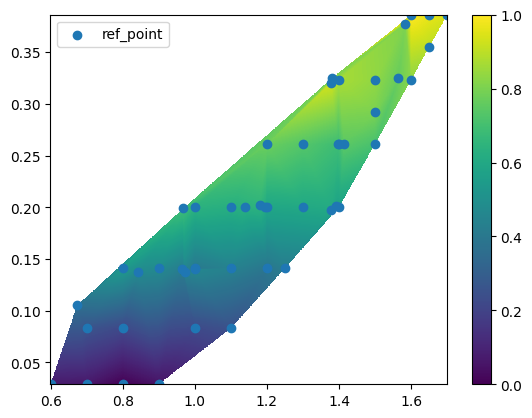

In [25]:
dfs['diesel_steam'] = dfs['diesel_steam'].dropna(subset=['sum_air'])

x = np.array(dfs['diesel_steam']['F_fuel'])
y = np.array(dfs['diesel_steam']['J'])
z = np.array(dfs['diesel_steam']['sum_air'])


X = np.linspace(dfs['diesel_steam']['F_fuel'].min(), dfs['diesel_steam']['F_fuel'].max(), 1_000)
Y = np.linspace(dfs['diesel_steam']['J'].min(), dfs['diesel_steam']['J'].max(), 1_000)
X, Y = np.meshgrid(X, Y)

interp = LinearNDInterpolator(list(zip(x, y)), z)
Z = interp(X, Y)

plt.pcolormesh(X, Y, Z)
plt.scatter(x, y, label='ref_point')
plt.legend()
plt.colorbar()

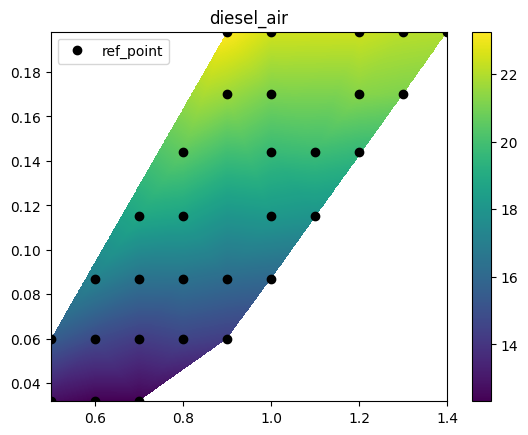

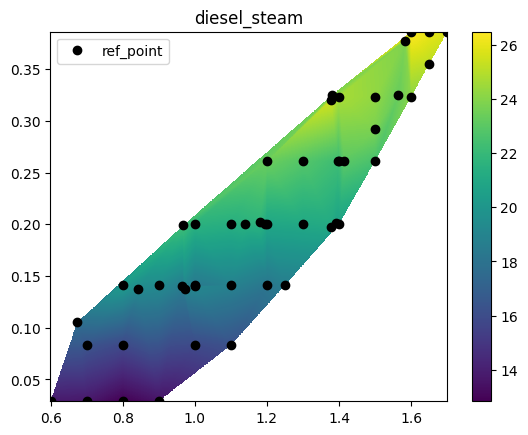

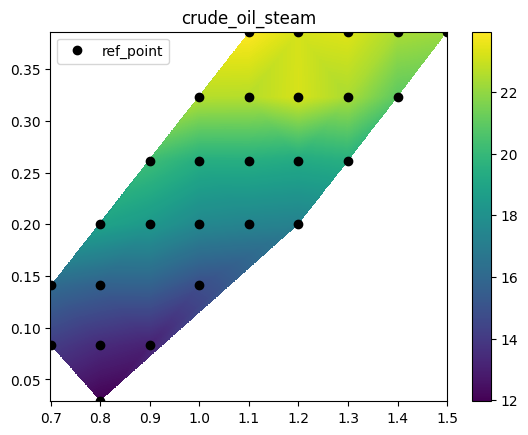

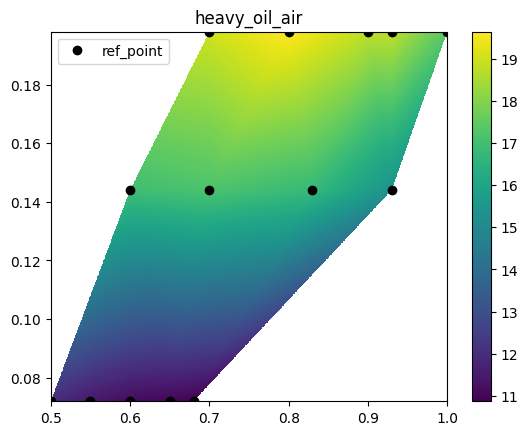

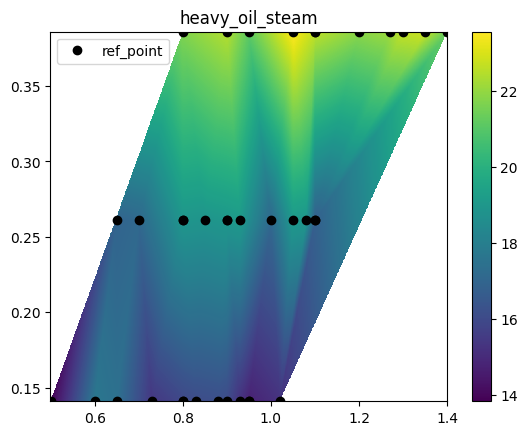

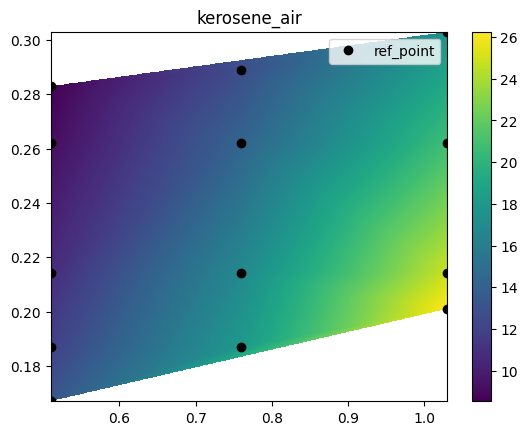

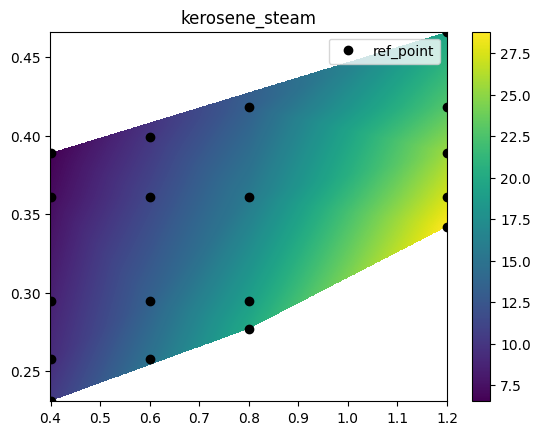

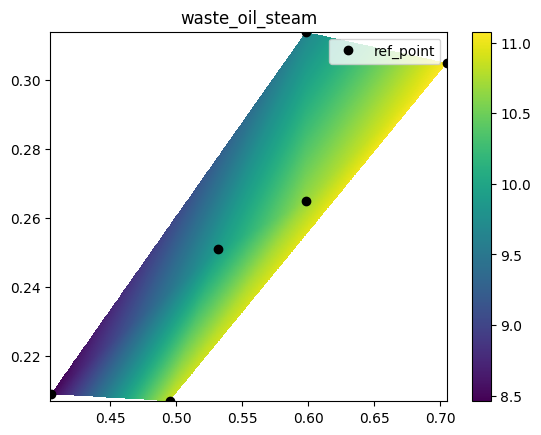

In [27]:
for key in dfs:
    dfs[key] = dfs[key].round(3)
    dfs[key] = dfs[key].dropna(subset=['sum_air'])
    
    x = np.array(dfs[key]['F_fuel'])
    y = np.array(dfs[key]['J'])
    z = np.array(dfs[key]['sum_air'])

    X = np.linspace(x.min(), x.max(), 1_000)
    Y = np.linspace(y.min(), y.max(), 1_000)
    X, Y = np.meshgrid(X, Y)

    interp = LinearNDInterpolator(list(zip(x, y)), z)
    Z = interp(X, Y)
    
    plt.pcolormesh(X, Y, Z, shading='auto')
    plt.plot(x, y, 'ok', label='ref_point')
    plt.legend()
    plt.colorbar()
   
    plt.title(key)
    
    plt.show()
    plt.close()